In [1]:
#Environment setup: installs and Drive mount
!pip install -q tensorflow librosa soundfile tqdm scikit-learn matplotlib

from google.colab import drive
drive.mount('/content/drive')

# Check TensorFlow and GPU
import tensorflow as tf
print("TF version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))


Mounted at /content/drive
TF version: 2.19.0
GPUs: []


In [2]:
import os
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/datasets"
assert os.path.exists(DATASET_PATH), f"Path not found: {DATASET_PATH}"

# List genres and first few files for quick verification
genres = [d for d in os.listdir(DATASET_PATH) if os.path.isdir(os.path.join(DATASET_PATH, d))]
print("Found genres:", genres)


# defaultdict to easily append files to lists
genre_files = defaultdict(list)

print("Searching for music files...")
for root, dirs, files in os.walk(DATASET_PATH):
    if root == DATASET_PATH:
        continue

    relative_path = os.path.relpath(root, DATASET_PATH)
    genre = relative_path.split(os.sep)[0]

    for file in files:
        if file.lower().endswith(".mp3"):
            full_path = os.path.join(root, file)
            genre_files[genre].append(full_path)

print("\n--- Scan Complete ---")
found_genres = list(genre_files.keys())
print("Found genres:", found_genres if found_genres else "None")

for genre, files in genre_files.items():
    example_filenames = [os.path.basename(f) for f in files[:3]]
    print(f"\n{genre}: {len(files)} mp3 files found (example 3):", example_filenames)

Found genres: ['Hip-Hop', 'film', 'Classical', 'Pop', 'metal', 'Folk', 'Devotional', 'EDM', 'Rock']
Searching for music files...

--- Scan Complete ---
Found genres: ['Hip-Hop', 'film', 'Classical', 'Pop', 'metal', 'Folk', 'Devotional', 'EDM', 'Rock']

Hip-Hop: 201 mp3 files found (example 3): ['hiphop_4.mp3', 'hiphop_2.mp3', 'hiphop_3.mp3']

film: 166 mp3 files found (example 3): ['film_55.mp3', 'film_52.mp3', 'film_50.mp3']

Classical: 150 mp3 files found (example 3): ['when-you-are-not-with-me-131721_01.mp3', 'the-adventures-of-mr-hardy_30sec-175535_02.mp3', 'remembering-you-130492_03.mp3']

Pop: 188 mp3 files found (example 3): ['popEnglish_01.mp3', 'popEnglish_03.mp3', 'popEnglish_04.mp3']

metal: 533 mp3 files found (example 3): ['Metal_01.mp3', 'Metal_02.mp3', 'Metal_03.mp3']

Folk: 210 mp3 files found (example 3): ['Folk_Telugu_46.mp3', 'Folk_Telugu_2.mp3', 'Folk_Telugu_21.mp3']

Devotional: 113 mp3 files found (example 3): ['Arey-O-Jangama_01.mp3', 'Bilwashtakam_02.mp3', 'Hara

In [5]:
# Feature extraction (with caching)
import librosa
import numpy as np
import os
from collections import defaultdict ### <<< ADDED
from tqdm import tqdm

DATASET_PATH = "/content/drive/MyDrive/ISBInternshipAIML/datasets"
assert os.path.exists(DATASET_PATH), f"Path not found: {DATASET_PATH}"
### -------------------------------------------------------------------- ###


FEATURES_FILE = "/content/drive/MyDrive/ISBInternshipAIML/features_mfcc_5s.npz"
SR = 22050          # sampling rate to use
DURATION = 5        # seconds to load from each MP3
N_MFCC = 20         # classical MFCC dimensionality

def extract_mfcc(file_path, sr=SR, duration=DURATION, n_mfcc=N_MFCC):
    try:
        y, sr_out = librosa.load(file_path, sr=sr, duration=duration)
        mfcc = librosa.feature.mfcc(y=y, sr=sr_out, n_mfcc=n_mfcc)
        mfcc_mean = np.mean(mfcc.T, axis=0)
        return mfcc_mean
    except Exception as e:
        print(f"Error processing {os.path.basename(file_path)}: {e}")
        return None

# If cached features already exist, load them
if os.path.exists(FEATURES_FILE):
    print("Loading cached features:", FEATURES_FILE)
    data = np.load(FEATURES_FILE, allow_pickle=True)
    X = data['X']
    y = data['y']
    label_map = data['label_map'].item()
else:
    print("Scanning all subfolders for music files...")
    genre_files = defaultdict(list)
    for root, dirs, files in os.walk(DATASET_PATH):
        if root == DATASET_PATH:
            continue
        relative_path = os.path.relpath(root, DATASET_PATH)
        genre = relative_path.split(os.sep)[0]
        for file in files:
            if file.lower().endswith(".mp3"):
                full_path = os.path.join(root, file)
                genre_files[genre].append(full_path)

    print(f"Scan complete. Found {sum(len(v) for v in genre_files.values())} files in {len(genre_files)} genres.")

    # 2. Now, process the collected files
    X_list, y_list = [], []
    label_map = {}
    next_label = 0
    for genre, file_paths in genre_files.items():
        # The 'file_paths' list already contains all mp3s for the genre from all subfolders
        for path in tqdm(file_paths, desc=f"Processing {genre}"):
            feat = extract_mfcc(path)
            # Only add the file if feature extraction was successful
            if feat is not None:
                X_list.append(feat)
                if genre not in label_map:
                    label_map[genre] = next_label
                    next_label += 1
                y_list.append(label_map[genre])

    X = np.vstack(X_list).astype(np.float32)
    y = np.array(y_list, dtype=np.int32)
    # Save to Drive for reuse
    np.savez(FEATURES_FILE, X=X, y=y, label_map=label_map)
    print("Saved features to", FEATURES_FILE)

print("X shape:", X.shape, "y shape:", y.shape, "label_map:", label_map)

Scanning all subfolders for music files...
Scan complete. Found 1867 files in 9 genres.


Processing Hip-Hop:  13%|█▎        | 26/201 [00:55<14:52,  5.10s/it]/tmp/ipython-input-1324126567.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_out = librosa.load(file_path, sr=sr, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing Hip-Hop:  13%|█▎        | 27/201 [00:55<10:46,  3.72s/it]

Error processing hiphop_19.mp3: 


/tmp/ipython-input-1324126567.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_out = librosa.load(file_path, sr=sr, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing Hip-Hop:  14%|█▍        | 28/201 [00:56<07:55,  2.75s/it]

Error processing hiphop_24.mp3: 


...

Error processing hiphop_149.mp3: 


Processing Hip-Hop:  69%|██████▉   | 139/201 [03:19<01:09,  1.12s/it]/tmp/ipython-input-1324126567.py:20: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr_out = librosa.load(file_path, sr=sr, duration=duration)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
Processing Hip-Hop:  70%|██████▉   | 140/201 [03:20<01:01,  1.01s/it]

Error processing hiphop_97.mp3: 


Processing Rock: 100%|██████████| 27/27 [00:31<00:00,  1.17s/it]

Saved features to /content/drive/MyDrive/ISBInternshipAIML/features_mfcc_5s.npz
X shape: (1863, 20) y shape: (1863,) label_map: {'Hip-Hop': 0, 'film': 1, 'Classical': 2, 'Pop': 3, 'metal': 4, 'Folk': 5, 'Devotional': 6, 'EDM': 7, 'Rock': 8}


In [6]:
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Train/Test split and tf.data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

BATCH_SIZE = 32

train_ds = tf.data.Dataset.from_tensor_slices((X_train, X_train)) \
    .shuffle(buffer_size=1000, seed=42) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

val_ds = tf.data.Dataset.from_tensor_slices((X_test, X_test)) \
    .batch(BATCH_SIZE) \
    .prefetch(tf.data.AUTOTUNE)

print("Training batches:", len(list(train_ds)))
print("Validation batches:", len(list(val_ds)))


Training batches: 47
Validation batches: 12


In [7]:
import tensorflow as tf
import numpy as np
from tqdm import tqdm

input_dim = X.shape[1]     # equals N_MFCC, e.g. 20
encoding_dim = 10          # bottleneck size; experiment with this

# Manual parameter initialization (encoder + decoder)
initializer = tf.random_normal_initializer(stddev=0.1)
W1 = tf.Variable(initializer([input_dim, encoding_dim]), name="W1")
b1 = tf.Variable(tf.zeros([encoding_dim]), name="b1")
W2 = tf.Variable(initializer([encoding_dim, input_dim]), name="W2")
b2 = tf.Variable(tf.zeros([input_dim]), name="b2")

opt = tf.keras.optimizers.Adam(learning_rate=0.01)

def forward(x):
    # x: (batch, input_dim)
    z = tf.nn.tanh(tf.matmul(x, W1) + b1)   # encoded: (batch, encoding_dim)
    x_recon = tf.nn.tanh(tf.matmul(z, W2) + b2)  # reconstructed: (batch, input_dim)
    return z, x_recon

def mse_loss(x, x_recon):
    return tf.reduce_mean(tf.math.squared_difference(x, x_recon))

# Training loop
EPOCHS = 50
best_val_loss = np.inf
WEIGHTS_SAVE = "/content/drive/MyDrive/ISBInternshipAIML/simple_autoencoder_weights.npz"

for epoch in range(1, EPOCHS + 1):
    # Training
    train_losses = []
    for batch_x, _ in train_ds:
        batch_x = tf.cast(batch_x, tf.float32)
        with tf.GradientTape() as tape:
            _, recon = forward(batch_x)
            loss = mse_loss(batch_x, recon)
        grads = tape.gradient(loss, [W1, b1, W2, b2])
        opt.apply_gradients(zip(grads, [W1, b1, W2, b2]))
        train_losses.append(loss.numpy())
    train_loss = np.mean(train_losses)

    # Validation
    val_losses = []
    for batch_x, _ in val_ds:
        batch_x = tf.cast(batch_x, tf.float32)
        _, recon = forward(batch_x)
        val_losses.append(mse_loss(batch_x, recon).numpy())
    val_loss = np.mean(val_losses)

    # Print progress
    print(f"Epoch {epoch:02d} | train_loss: {train_loss:.6f} | val_loss: {val_loss:.6f}")

    # Save best weights
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        np.savez(WEIGHTS_SAVE,
                 W1=W1.numpy(), b1=b1.numpy(),
                 W2=W2.numpy(), b2=b2.numpy(), encoding_dim=encoding_dim)
        print("  --> saved best weights")


Epoch 01 | train_loss: 4831.899414 | val_loss: 4301.158691
  --> saved best weights
Epoch 02 | train_loss: 4823.792969 | val_loss: 4299.336426
  --> saved best weights
Epoch 03 | train_loss: 4903.745117 | val_loss: 4298.846191
  --> saved best weights
Epoch 04 | train_loss: 4815.529785 | val_loss: 4298.634766
  --> saved best weights
Epoch 05 | train_loss: 4814.484863 | val_loss: 4298.468262
  --> saved best weights
Epoch 06 | train_loss: 4827.337891 | val_loss: 4298.302246
  --> saved best weights
Epoch 07 | train_loss: 4812.974609 | val_loss: 4298.217773
  --> saved best weights
Epoch 08 | train_loss: 4802.668457 | val_loss: 4298.105957
  --> saved best weights
Epoch 09 | train_loss: 4845.753418 | val_loss: 4297.472656
  --> saved best weights
Epoch 10 | train_loss: 4811.515137 | val_loss: 4297.100586
  --> saved best weights
Epoch 11 | train_loss: 4811.705078 | val_loss: 4296.963379
  --> saved best weights
Epoch 12 | train_loss: 4813.882324 | val_loss: 4296.695801
  --> saved best 

Test MSE (reconstruction): 4308.7007


/tmp/ipython-input-2421706784.py:30: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


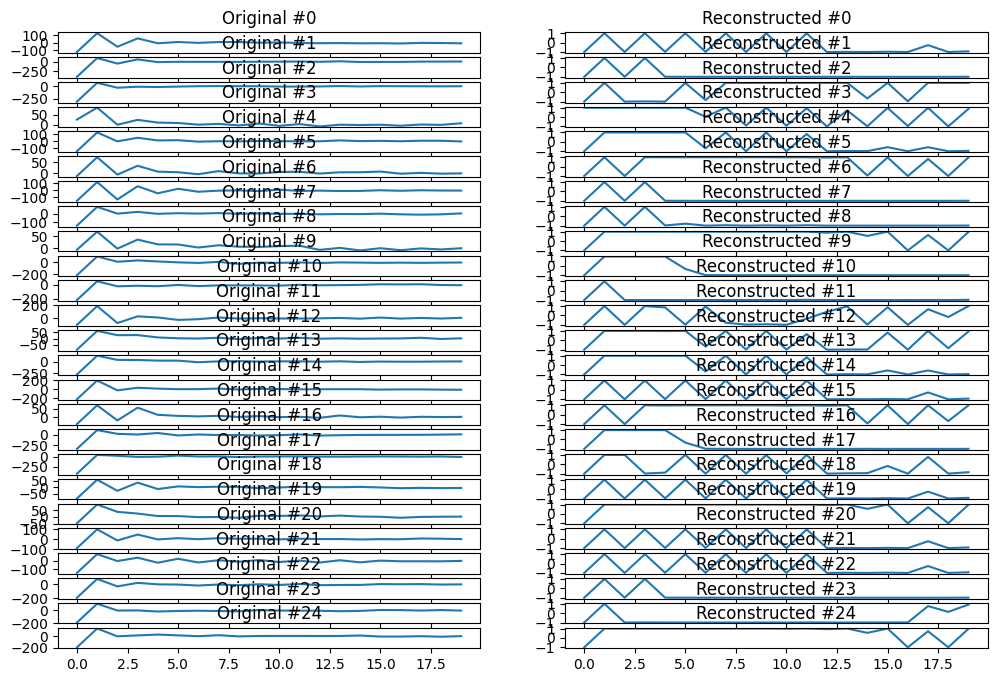

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Load saved weights (if needed)
data = np.load(WEIGHTS_SAVE)
W1.assign(data['W1'])
b1.assign(data['b1'])
W2.assign(data['W2'])
b2.assign(data['b2'])

# Evaluate on test set (X_test)
X_test_tf = tf.cast(X_test, tf.float32)
z_test, recon_test = forward(X_test_tf)
recon_np = recon_test.numpy()

# Compute overall MSE
mse_total = np.mean((X_test - recon_np)**2)
print("Test MSE (reconstruction):", mse_total)

# Plot first 6 samples: original vs reconstructed
num_plot = min(25, X_test.shape[0])
plt.figure(figsize=(12, 8))
for i in range(num_plot):
    plt.subplot(num_plot, 2, 2*i + 1)
    plt.title(f"Original #{i}")
    plt.plot(X_test[i])
    plt.subplot(num_plot, 2, 2*i + 2)
    plt.title(f"Reconstructed #{i}")
    plt.plot(recon_np[i])
plt.tight_layout()
plt.show()


Saved latent embeddings.


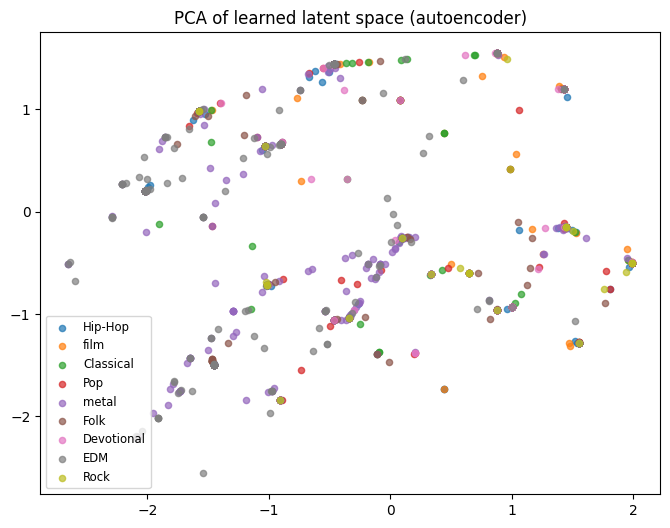

In [10]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Encode ALL examples (X)
X_tf_all = tf.cast(X, tf.float32)
z_all, _ = forward(X_tf_all)
Z = z_all.numpy()   # shape (N, encoding_dim)

# Save latent embeddings for later use
np.savez("/content/drive/MyDrive/ISBInternshipAIML/latent_embeddings.npz", Z=Z, y=y, label_map=label_map)
print("Saved latent embeddings.")

# KMeans with k = number of genres
k = len(label_map)
km = KMeans(n_clusters=k, random_state=42).fit(Z)
labels_km = km.labels_

# PCA to 2D for visualization
pca = PCA(n_components=2, random_state=42)
Z2 = pca.fit_transform(Z)

# Create a color map for genres
inv_label_map = {v:k for k,v in label_map.items()}
colors = [inv_label_map[int(lbl)] for lbl in y]  # genre names

plt.figure(figsize=(8,6))
for genre_name, genre_idx in label_map.items():
    mask = (y == genre_idx)
    plt.scatter(Z2[mask,0], Z2[mask,1], label=genre_name, alpha=0.7, s=20)
plt.legend(loc='best', fontsize='small')
plt.title("PCA of learned latent space (autoencoder)")
plt.show()
